# Spam Mail Prediction using Machine Learning

End-to-end pipeline: data cleaning, feature extraction (TF-IDF), and comparison of multiple classification models (Logistic Regression, Naive Bayes, SVM) for spam vs. ham classification.

## 1. Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style('whitegrid')

## 2. Data Collection & Pre-Processing

In [2]:
# loading the data from csv file to a pandas Dataframe
raw_mail_data = pd.read_csv('/content/mail_data.csv')
print(raw_mail_data.shape)
raw_mail_data.head()

(14926, 2)


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# replace the null values with a null string
mail_data = raw_mail_data.where((pd.notnull(raw_mail_data)), '')

### Checking for duplicate records
Duplicate rows can leak across the train/test split, artificially inflating evaluation metrics. We check for and remove them before splitting.

In [4]:
print("Duplicate rows found:", mail_data.duplicated().sum())

Duplicate rows found: 3749


In [5]:
mail_data = mail_data.drop_duplicates()
print("Shape after removing duplicates:", mail_data.shape)

Shape after removing duplicates: (11177, 2)


In [6]:
print(mail_data['Category'].value_counts())

Category
ham     8825
spam    2352
Name: count, dtype: int64


## 3. Label Encoding

spam = 0, ham = 1

In [7]:
mail_data.loc[mail_data['Category'] == 'spam', 'Category'] = 0
mail_data.loc[mail_data['Category'] == 'ham', 'Category'] = 1

In [8]:
X = mail_data['Message']
Y = mail_data['Category']

## 4. Splitting the data into training data & test data

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=3)

print(X.shape)
print(X_train.shape)
print(X_test.shape)

(11177,)
(8941,)
(2236,)


## 5. Feature Extraction (TF-IDF)

Convert raw text into numeric feature vectors. `fit_transform` is used on training data (learns vocabulary + transforms), while `transform` (not `fit_transform`) is used on test data to avoid data leakage.

In [10]:
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)

X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')

print(X_train_features.shape)

(8941, 70013)


### Helper function for plotting confusion matrices\n\nReused for every model below so all results are visually consistent and easy to compare.

In [11]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['spam','ham'], yticklabels=['spam','ham'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

## 6. Model 1 — Logistic Regression (Default)

In [12]:
model_default = LogisticRegression()
model_default.fit(X_train_features, Y_train)

train_pred = model_default.predict(X_train_features)
test_pred = model_default.predict(X_test_features)

print("Training Accuracy:", accuracy_score(Y_train, train_pred))
print("Test Accuracy:", accuracy_score(Y_test, test_pred))

Training Accuracy: 0.9668940834358573
Test Accuracy: 0.9561717352415027


              precision    recall  f1-score   support

        spam       0.99      0.81      0.89       485
         ham       0.95      1.00      0.97      1751

    accuracy                           0.96      2236
   macro avg       0.97      0.90      0.93      2236
weighted avg       0.96      0.96      0.95      2236



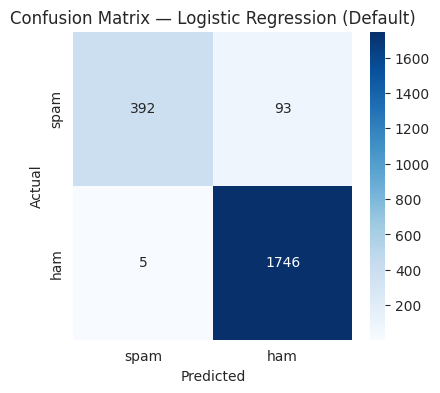

In [13]:
print(classification_report(Y_test, test_pred, target_names=['spam', 'ham']))
plot_confusion_matrix(Y_test, test_pred, 'Confusion Matrix — Logistic Regression (Default)')

## 7. Model 2 — Logistic Regression (class_weight='balanced')

Since the dataset is imbalanced (~79% ham / 21% spam), class weighting tells the model to penalize mistakes on the minority class (spam) more heavily.

In [14]:
model_balanced = LogisticRegression(class_weight='balanced')
model_balanced.fit(X_train_features, Y_train)

train_pred_bal = model_balanced.predict(X_train_features)
test_pred_bal = model_balanced.predict(X_test_features)

print("Training Accuracy:", accuracy_score(Y_train, train_pred_bal))
print("Test Accuracy:", accuracy_score(Y_test, test_pred_bal))

Training Accuracy: 0.9881445028520299
Test Accuracy: 0.9695885509838998


              precision    recall  f1-score   support

        spam       0.92      0.94      0.93       485
         ham       0.98      0.98      0.98      1751

    accuracy                           0.97      2236
   macro avg       0.95      0.96      0.96      2236
weighted avg       0.97      0.97      0.97      2236



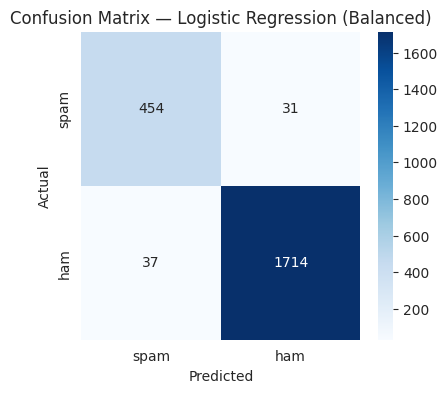

In [15]:
print(classification_report(Y_test, test_pred_bal, target_names=['spam', 'ham']))
plot_confusion_matrix(Y_test, test_pred_bal, 'Confusion Matrix — Logistic Regression (Balanced)')

## 8. Decision Threshold Tuning

Instead of the default 0.5 probability cutoff, we test different thresholds to explore the precision-recall trade-off directly (fewer false positives vs. fewer false negatives).

In [16]:
def threshold_report(model, X_features, Y_true, thresholds=[0.5, 0.6, 0.7, 0.8, 0.9]):
    probs = model.predict_proba(X_features)
    spam_probs = probs[:, 0]  # probability of spam (class 0)
    for t in thresholds:
        preds = np.where(spam_probs >= t, 0, 1)
        cm = confusion_matrix(Y_true, preds)
        fp = cm[1][0]  # real ham wrongly called spam
        fn = cm[0][1]  # real spam wrongly called ham
        print(f"Threshold: {t} | False Positives (ham->spam): {fp} | False Negatives (spam->ham): {fn}")

print("Default Logistic Regression:")
threshold_report(model_default, X_test_features, Y_test)

print("\nBalanced Logistic Regression:")
threshold_report(model_balanced, X_test_features, Y_test)

Default Logistic Regression:
Threshold: 0.5 | False Positives (ham->spam): 5 | False Negatives (spam->ham): 93
Threshold: 0.6 | False Positives (ham->spam): 4 | False Negatives (spam->ham): 125
Threshold: 0.7 | False Positives (ham->spam): 3 | False Negatives (spam->ham): 178
Threshold: 0.8 | False Positives (ham->spam): 3 | False Negatives (spam->ham): 224
Threshold: 0.9 | False Positives (ham->spam): 2 | False Negatives (spam->ham): 317

Balanced Logistic Regression:
Threshold: 0.5 | False Positives (ham->spam): 37 | False Negatives (spam->ham): 31
Threshold: 0.6 | False Positives (ham->spam): 16 | False Negatives (spam->ham): 48
Threshold: 0.7 | False Positives (ham->spam): 6 | False Negatives (spam->ham): 85
Threshold: 0.8 | False Positives (ham->spam): 4 | False Negatives (spam->ham): 118
Threshold: 0.9 | False Positives (ham->spam): 3 | False Negatives (spam->ham): 206


## 9. Model 3 — Naive Bayes (MultinomialNB)

In [17]:
nb_model = MultinomialNB()
nb_model.fit(X_train_features, Y_train)

nb_train_pred = nb_model.predict(X_train_features)
nb_test_pred = nb_model.predict(X_test_features)

print("Naive Bayes - Training Accuracy:", accuracy_score(Y_train, nb_train_pred))
print("Naive Bayes - Test Accuracy:", accuracy_score(Y_test, nb_test_pred))

Naive Bayes - Training Accuracy: 0.9287551727994632
Naive Bayes - Test Accuracy: 0.9042933810375671


              precision    recall  f1-score   support

        spam       0.99      0.56      0.72       485
         ham       0.89      1.00      0.94      1751

    accuracy                           0.90      2236
   macro avg       0.94      0.78      0.83      2236
weighted avg       0.91      0.90      0.89      2236



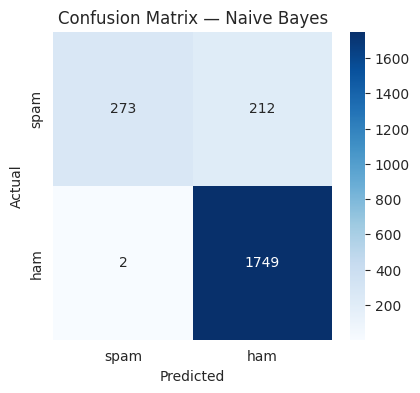

In [18]:
print(classification_report(Y_test, nb_test_pred, target_names=['spam', 'ham']))
plot_confusion_matrix(Y_test, nb_test_pred, 'Confusion Matrix — Naive Bayes')

## 10. Model 4 — Support Vector Machine (LinearSVC)

In [19]:
svm_model = LinearSVC()
svm_model.fit(X_train_features, Y_train)

svm_train_pred = svm_model.predict(X_train_features)
svm_test_pred = svm_model.predict(X_test_features)

print("SVM - Training Accuracy:", accuracy_score(Y_train, svm_train_pred))
print("SVM - Test Accuracy:", accuracy_score(Y_test, svm_test_pred))

SVM - Training Accuracy: 0.9989934011855497
SVM - Test Accuracy: 0.9794275491949911


              precision    recall  f1-score   support

        spam       0.98      0.93      0.95       485
         ham       0.98      0.99      0.99      1751

    accuracy                           0.98      2236
   macro avg       0.98      0.96      0.97      2236
weighted avg       0.98      0.98      0.98      2236



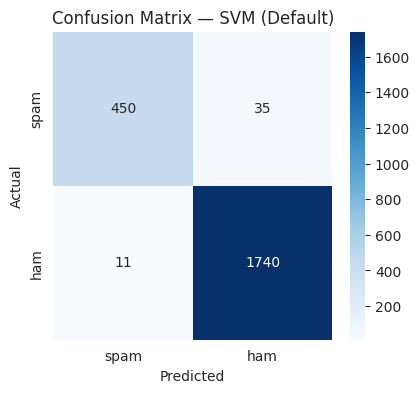

In [20]:
print(classification_report(Y_test, svm_test_pred, target_names=['spam', 'ham']))
plot_confusion_matrix(Y_test, svm_test_pred, 'Confusion Matrix — SVM (Default)')

## 11. Model 5 — SVM (class_weight='balanced')

In [21]:
svm_balanced = LinearSVC(class_weight='balanced')
svm_balanced.fit(X_train_features, Y_train)

svm_bal_train_pred = svm_balanced.predict(X_train_features)
svm_bal_test_pred = svm_balanced.predict(X_test_features)

print("SVM (balanced) - Training Accuracy:", accuracy_score(Y_train, svm_bal_train_pred))
print("SVM (balanced) - Test Accuracy:", accuracy_score(Y_test, svm_bal_test_pred))

SVM (balanced) - Training Accuracy: 0.998546023934683
SVM (balanced) - Test Accuracy: 0.9807692307692307


              precision    recall  f1-score   support

        spam       0.97      0.94      0.95       485
         ham       0.98      0.99      0.99      1751

    accuracy                           0.98      2236
   macro avg       0.98      0.97      0.97      2236
weighted avg       0.98      0.98      0.98      2236



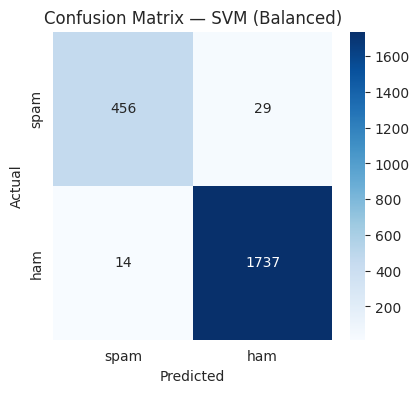

In [22]:
print(classification_report(Y_test, svm_bal_test_pred, target_names=['spam', 'ham']))
plot_confusion_matrix(Y_test, svm_bal_test_pred, 'Confusion Matrix — SVM (Balanced)')

## 12. Model Comparison Summary

Accuracy alone can be misleading on an imbalanced dataset, so models are compared on precision, recall, and F1-score for the spam class as well.

In [23]:
results = {
    'Naive Bayes': accuracy_score(Y_test, nb_test_pred),
    'Logistic Regression (default)': accuracy_score(Y_test, test_pred),
    'Logistic Regression (balanced)': accuracy_score(Y_test, test_pred_bal),
    'SVM (default)': accuracy_score(Y_test, svm_test_pred),
    'SVM (balanced)': accuracy_score(Y_test, svm_bal_test_pred),
}

for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

Naive Bayes: 0.9043
Logistic Regression (default): 0.9562
Logistic Regression (balanced): 0.9696
SVM (default): 0.9794
SVM (balanced): 0.9808


### Visual comparison of all models; Comparing precision, recall, and F1-score (for the spam class) side by side, since accuracy alone can be misleading on an imbalanced dataset.

                Precision  Recall  F1-score
Model                                      
Naive Bayes         0.993   0.563     0.718
LR (default)        0.987   0.808     0.889
LR (balanced)       0.925   0.936     0.930
SVM (default)       0.976   0.928     0.951
SVM (balanced)      0.970   0.940     0.955


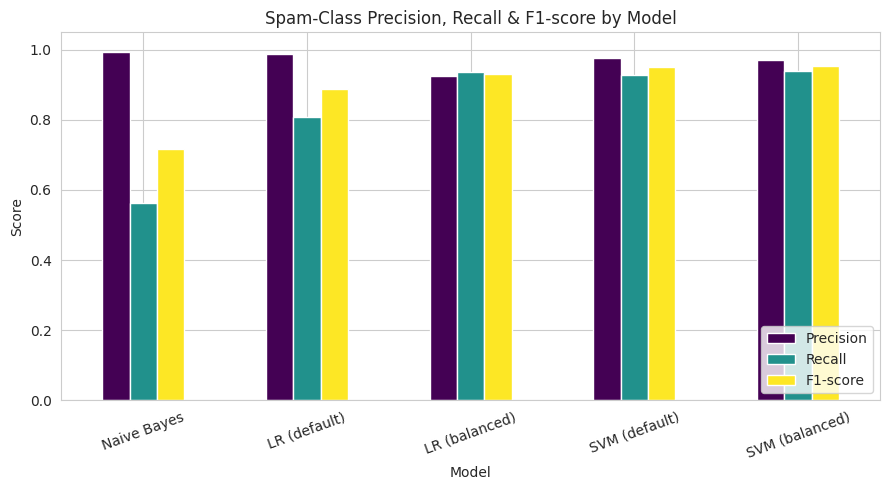

In [24]:
from sklearn.metrics import precision_recall_fscore_support

model_preds = {
    'Naive Bayes': nb_test_pred,
    'LR (default)': test_pred,
    'LR (balanced)': test_pred_bal,
    'SVM (default)': svm_test_pred,
    'SVM (balanced)': svm_bal_test_pred,
}

rows = []
for name, preds in model_preds.items():
    p, r, f1, _ = precision_recall_fscore_support(Y_test, preds, labels=[0], average=None)
    rows.append({'Model': name, 'Precision': p[0], 'Recall': r[0], 'F1-score': f1[0]})

comparison_df = pd.DataFrame(rows).set_index('Model')
print(comparison_df.round(3))

comparison_df.plot(kind='bar', figsize=(9,5), colormap='viridis')
plt.title('Spam-Class Precision, Recall & F1-score by Model')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Summary of findings:**

| Model | Accuracy | Spam Precision | Spam Recall | Spam F1 |
|---|---|---|---|---|
| Naive Bayes | ~0.90 | ~0.99 | ~0.56 | ~0.72 |
| Logistic Regression (default) | ~0.96 | ~0.99 | ~0.81 | ~0.89 |
| Logistic Regression (balanced) | ~0.97 | ~0.92 | ~0.94 | ~0.93 |
| SVM (default) | ~0.98 | ~0.98 | ~0.93 | ~0.95 |
| SVM (balanced) | ~0.98 | ~0.97 | ~0.94 | ~0.95 |

**SVM (default)** — best overall balance between catching spam (recall) and avoiding false alarms on legitimate messages (precision).

## 13. Building a Predictive System

In [25]:
final_model = svm_model  # change this to whichever model you choose as final

input_mail = ["I've been searching for the right words to thank you for this breather. "
              "I promise i wont take your help for granted and will fulfil my promise. "
              "You have been wonderful and a blessing at all times"]

input_data_features = feature_extraction.transform(input_mail)
prediction = final_model.predict(input_data_features)

print(prediction)
if prediction[0] == 1:
    print('Ham mail')
else:
    print('Spam mail')

[1]
Ham mail
